# Quality control with GrandQC - find the artifacts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CraigMyles/raw2features/blob/main/notebooks/05_quality_control.ipynb)

Slide scans pick up **artifacts** - out-of-focus blur, tissue folds, pen marks, air
bubbles, dust. Embedding those patches feeds bad signal into whatever you train downstream.
[GrandQC](https://doi.org/10.1038/s41467-024-54769-y) is a segmentation model that labels
them; `raw2features` runs it as an optional **`--qc grandqc`** layer that scores *every
patch* for each artifact class, so you can rank slides, locate the artifacts, and drop
bad patches before they reach your model.

This notebook: embed a few slides → **rank them by artifact burden** → **map** where the
artifacts are → **gallery** the worst patches → **filter** features by QC.

> GrandQC weights are **CC-BY-NC-SA-4.0 (non-commercial)**, fetched on first use, never
> bundled. They are a preprocessing aid; your embeddings are not derivatives of them.

In [1]:
# Bootstrap: works on Colab and a local install.
import importlib.util, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
HAVE_PKG = importlib.util.find_spec("raw2features") is not None
EXTRAS = "zarr,image,torch,models,grandqc"
SPEC = f"raw2features[{EXTRAS}]"  # PyPI; pin a version (==0.1.0) for reproducibility
if IN_COLAB or not HAVE_PKG:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", SPEC])

import glob, os, tempfile
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import raw2features
from raw2features.core.geometry import Point, Region, Size
from raw2features.core.store import GRIDS, grid_keys, open_root
from raw2features.pipeline.runner import slide_id_from_path
from raw2features.readers.omezarr import OmeZarrReader
from raw2features.viz import render_thumbnail

mpl.rcParams["figure.dpi"] = 88
WORK = tempfile.mkdtemp(prefix="r2f_qc_")
print("raw2features", raw2features.__version__)

raw2features 0.1.0


## 1. Pick some slides

Point `SLIDES` at your own OME-Zarr H&E (set `R2F_SLIDES` to a folder). With nothing local
we stream a real public H&E slide from the
[BioImage Archive](https://www.ebi.ac.uk/biostudies/studies/S-BIAD1285) (the SurGen study),
so QC runs on **genuine tissue** rather than a trivial synthetic.

> The BIA OME-Zarr URLs are an *access service* and may change over time; only the accession
> is permanent. See [`02_visual_walkthrough.ipynb`](02_visual_walkthrough.ipynb) for the full note.

In [2]:
import urllib.request, xml.etree.ElementTree as ET

_BIA_S3 = "https://uk1s3.embassy.ebi.ac.uk/bia-integrator-data"
_NS = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}

def _bia_prefixes(prefix):
    url = f"{_BIA_S3}?list-type=2&prefix={prefix}&delimiter=/"
    root = ET.fromstring(urllib.request.urlopen(url, timeout=60).read())
    return [p.text for p in root.findall(".//s3:CommonPrefixes/s3:Prefix", _NS)]

def surgen_slides(n, accession="S-BIAD1285"):
    """Resolve up to n *readable* public OME-Zarr H&E URIs from a BioImage Archive study.

    Some depositions include reps we can't open as a pyramid; we skip those so the demo
    always lands on usable slides.
    """
    out = []
    for img in _bia_prefixes(f"{accession}/"):
        for rep in _bia_prefixes(img):
            if not rep.rstrip("/").endswith(".ome.zarr"):
                continue
            url = f"{_BIA_S3}/{rep.rstrip('/')}"
            try:
                with OmeZarrReader(url) as r:
                    r.level_downsamples()
                out.append(url)
            except Exception:
                pass
            break
        if len(out) >= n:
            break
    return out

slide_dir = os.environ.get("R2F_SLIDES", "../dev-data")
SLIDES = [s for s in sorted(glob.glob(os.path.join(slide_dir, "*.zarr")))
          if "multiplex" not in s]  # GrandQC is an H&E (RGB) model
if not SLIDES:
    SLIDES = surgen_slides(2)  # stream a couple of real public SurGen H&E slides
    print("no local slides - streaming public SurGen slides from the BioImage Archive")
print(f"{len(SLIDES)} slide(s):")
for s in SLIDES:
    print("  ", os.path.basename(s.rstrip("/")))

no local slides - streaming public SurGen slides from the BioImage Archive
2 slide(s):
   b2f711e1-8088-4d67-937e-2ff20e2f89d2.ome.zarr
   0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd.ome.zarr


## 2. Embed each slide and run the GrandQC QC layer

A light patch model (`resnet50`) at a coarse **2 µm/px** keeps the cloud slide quick. The
`--qc grandqc` layer (per-patch scores in `grids/<key>/qc/grandqc/`) runs with two cohort
adjustments: **Macenko** normalization (`--qc-stain-norm macenko`) for the stain, and a
coarser **artifact scale** (`--qc-artifact-mpp 2.0`) that is less focus-sensitive. Both are
essential here - the before/after below shows why. (Skipped if a store already exists.)

In [3]:
def store_for(slide):
    # match the embed's output name exactly (strips .ome.zarr, not just .zarr)
    return os.path.join(WORK, f"{slide_id_from_path(slide)}.embeddings.zarr")

for slide in SLIDES:
    if os.path.exists(store_for(slide)):
        continue
    subprocess.check_call([
        sys.executable, "-m", "raw2features", "embed", slide, WORK,
        "-m", "resnet50", "--qc", "grandqc",
        "--qc-stain-norm", "macenko", "--qc-artifact-mpp", "2.0",
        "--mpp", "2.0", "--device", "auto", "--batch-size", "128",
    ])
print("done - stores in", WORK)

slide_id: b2f711e1-8088-4d67-937e-2ff20e2f89d2
status: complete
grids: {'mpp2_px224': ['resnet50']}
output_uri: file:///tmp/r2f_qc_pl8n8yac/b2f711e1-8088-4d67-937e-2ff20e2f89d2.embeddings.zarr
per_grid: [{'slide_id': 'b2f711e1-8088-4d67-937e-2ff20e2f89d2', 'status': 'complete', 'n_patches': 536, 'models': ['resnet50'], 'models_added': ['resnet50'], 'models_skipped': [], 'slide_embeddings': {}, 'output_uri': 'file:///tmp/r2f_qc_pl8n8yac/b2f711e1-8088-4d67-937e-2ff20e2f89d2.embeddings.zarr', 'geojson': None, 'thumbnail': None, 'elapsed_s': 29.58}]
elapsed_s: 30.13


slide_id: 0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd
status: complete
grids: {'mpp2_px224': ['resnet50']}
output_uri: file:///tmp/r2f_qc_pl8n8yac/0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd.embeddings.zarr
per_grid: [{'slide_id': '0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd', 'status': 'complete', 'n_patches': 65, 'models': ['resnet50'], 'models_added': ['resnet50'], 'models_skipped': [], 'slide_embeddings': {}, 'output_uri': 'file:///tmp/r2f_qc_pl8n8yac/0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd.embeddings.zarr', 'geojson': None, 'thumbnail': None, 'elapsed_s': 9.57}]
elapsed_s: 10.1


done - stores in /tmp/r2f_qc_pl8n8yac


## Tuning GrandQC for this cohort (before/after)

GrandQC is trained on particular stains and scanners, so out-of-the-box it **over-flags** a
differently-stained, softer-scanned cohort - mostly as out-of-focus. Two knobs bring it in
line: **Macenko** normalization (`--qc-stain-norm macenko`) for the stain, and a coarser
**artifact scale** (`--qc-artifact-mpp 2.0`, less focus-sensitive) for the softer scans.
Here is one slide out-of-the-box vs tuned; we use the tuned settings throughout.

The maps look blocky because GrandQC segments in 512 px tiles: a uniformly out-of-focus
region fills a whole tile, while tissue edges resolve to fine per-pixel outlines.

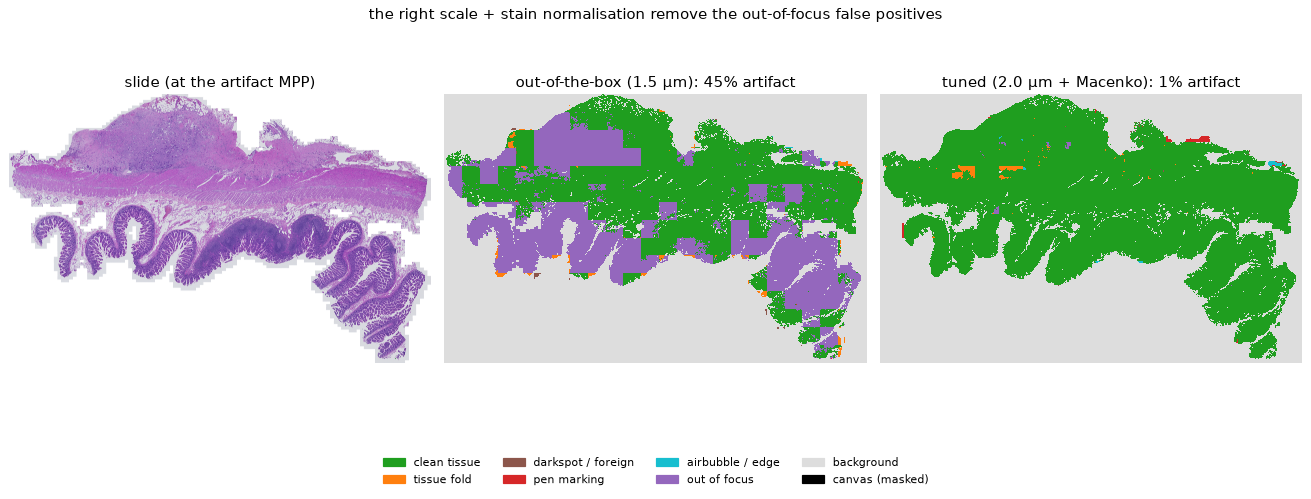

In [4]:
from matplotlib.colors import ListedColormap
from raw2features.qc.grandqc import GrandQC
import torch
import matplotlib.patches as mpatches

DEV = "cuda" if torch.cuda.is_available() else "cpu"
# class index -> colour: 0 bg | 1 clean | 2 fold | 3 darkspot | 4 pen | 5 bubble | 6 oof | 7 bg
_CMAP = ListedColormap(["#000000", "#1f9e1f", "#ff7f0e", "#8c564b",
                        "#d62728", "#17becf", "#9467bd", "#dddddd"])

def artifact_fraction(raster, raw_img):
    """Fraction of detected tissue flagged as any artifact class (canvas masked)."""
    hh, ww = min(raster.shape[0], raw_img.shape[0]), min(raster.shape[1], raw_img.shape[1])
    r = raster[:hh, :ww].copy()
    r[raw_img[:hh, :ww].max(2) < 10] = 0              # drop black scanner canvas
    counts = np.bincount(r.ravel(), minlength=8).astype(float)
    return counts[2:7].sum() / (counts[1:7].sum() or 1.0), r

demo = SLIDES[0]
with OmeZarrReader(demo) as reader:
    default = GrandQC(device=DEV, artifact_mpp="1.5")                       # out-of-the-box
    ras_d, _ = default.artifact_raster(reader); img_d, _ = default.artifact_image(reader)
    tuned = GrandQC(device=DEV, artifact_mpp="2.0", stain_norm="macenko")   # tuned for cohort
    ras_t, _ = tuned.artifact_raster(reader); img_t, _ = tuned.artifact_image(reader)

frac_d, masked_d = artifact_fraction(ras_d, img_d)
frac_t, masked_t = artifact_fraction(ras_t, img_t)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6))
axes[0].imshow(img_t); axes[0].set_title("slide (at the artifact MPP)")
axes[1].imshow(masked_d, cmap=_CMAP, vmin=0, vmax=7, interpolation="nearest")
axes[1].set_title(f"out-of-the-box (1.5 \u00b5m): {frac_d:.0%} artifact")
axes[2].imshow(masked_t, cmap=_CMAP, vmin=0, vmax=7, interpolation="nearest")
axes[2].set_title(f"tuned (2.0 \u00b5m + Macenko): {frac_t:.0%} artifact")
for ax in axes:
    ax.axis("off")
# colour key for the GrandQC class rasters (panels 2 and 3)
_KEY = {1: "clean tissue", 2: "tissue fold", 3: "darkspot / foreign", 4: "pen marking",
        5: "airbubble / edge", 6: "out of focus", 7: "background", 0: "canvas (masked)"}
handles = [mpatches.Patch(color=_CMAP.colors[v], label=lab) for v, lab in _KEY.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.01), fontsize=9)
fig.suptitle("the right scale + stain normalisation remove the out-of-focus false positives")
plt.tight_layout(rect=(0, 0.12, 1, 1)); plt.show()

## 3. Rank slides by artifact burden

For each slide we load `qc/grandqc/scores` - an `(n_patches, 7)` array of the *coverage
fraction* of each class per patch. **Artifact burden** = the mean fraction of patch area
that is any non-clean, non-background class. `% dirty patches` counts patches that are
≥25% artifact.

In [5]:
ARTIFACTS = ["tissue_fold", "darkspot_foreign", "pen_marking",
             "airbubble_edge", "out_of_focus"]

def load_qc(store):
    root = open_root(store)
    for k in grid_keys(root):
        g = root[GRIDS][k]
        if "qc" in g and "grandqc" in g["qc"]:
            arr = g["qc"]["grandqc"]["scores"]
            classes = list(arr.attrs["classes"])
            hdr = dict(g.attrs["raw2features"])
            return {
                "grid": k,
                "coords": np.asarray(g["coords"][:]),
                "scores": np.asarray(arr[:]).astype("float32"),
                "classes": classes,
                "level0_patch": int(hdr["patching"]["level0_patch"]),
            }
    return None

records, rows = {}, []
for slide in SLIDES:
    qc = load_qc(store_for(slide))
    if qc is None:
        continue
    records[slide] = qc
    idx = {c: i for i, c in enumerate(qc["classes"])}
    art = qc["scores"][:, [idx[a] for a in ARTIFACTS]]
    burden = art.sum(1)  # artifact fraction per patch
    row = {"slide": os.path.basename(slide), "n_patches": len(burden),
           "artifact_burden": burden.mean(),
           "%_dirty(>=0.25)": 100 * (burden >= 0.25).mean()}
    row.update({a: qc["scores"][:, idx[a]].mean() for a in ARTIFACTS})
    rows.append(row)

rank = pd.DataFrame(rows).sort_values("artifact_burden", ascending=False)
rank.set_index("slide").style.format("{:.3f}").background_gradient(
    subset=["artifact_burden"], cmap="Reds")

,n_patches,artifact_burden,%_dirty(>=0.25),tissue_fold,darkspot_foreign,pen_marking,airbubble_edge,out_of_focus
slide,,,,,,,,
0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd.ome.zarr,65.000,0.038,6.154,0.010,0.001,0.027,0.000,0.000
b2f711e1-8088-4d67-937e-2ff20e2f89d2.ome.zarr,536.000,0.012,1.493,0.006,0.000,0.003,0.001,0.002


## 4. Where are the artifacts?

Map each per-patch class fraction back onto a thumbnail of the dirtiest slide. Bright = a
lot of that class. This is the per-patch QC made visible.

Text(0.5, 0.98, 'per-patch artifact maps - bright = more of that class')

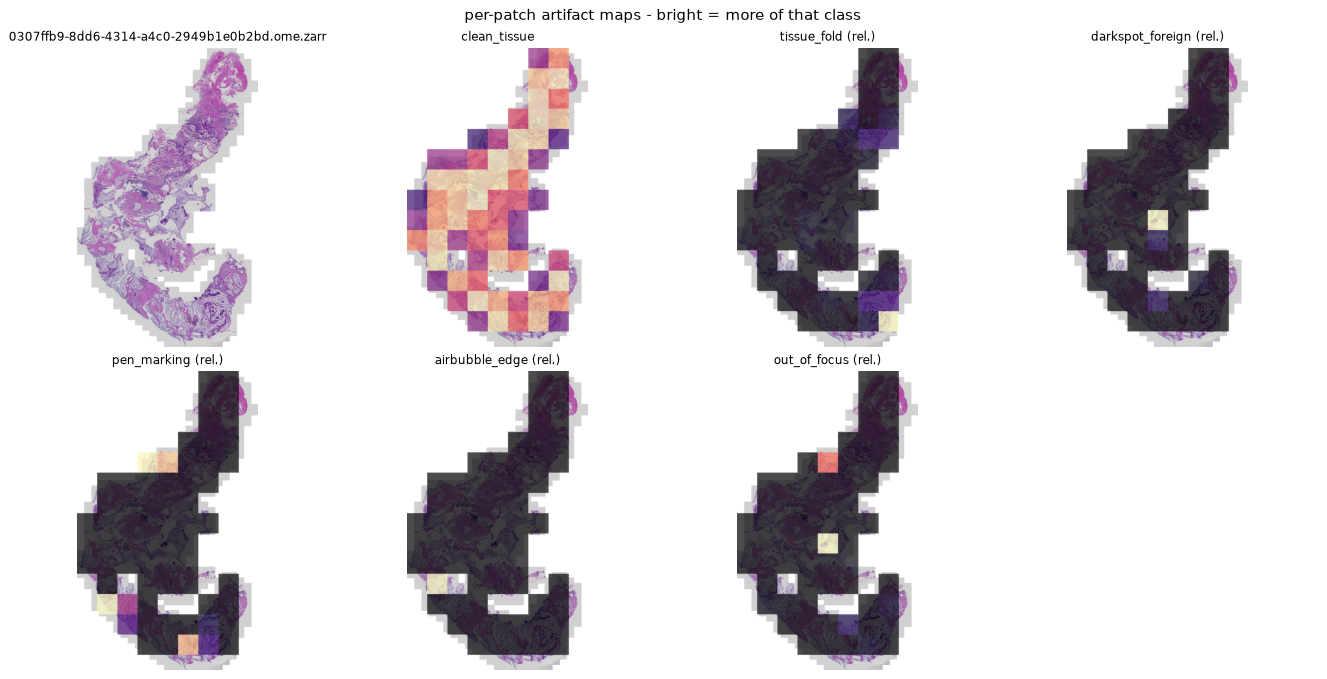

In [6]:
worst = rank.iloc[0]["slide"]
slide = next(s for s in SLIDES if os.path.basename(s) == worst)
qc = records[slide]
idx = {c: i for i, c in enumerate(qc["classes"])}
with OmeZarrReader(slide) as r:
    thumb = render_thumbnail(r, max_px=1400)

ds = thumb.downsample
side = max(1, round(qc["level0_patch"] / ds))
px = np.round(qc["coords"] / ds).astype(int)            # patch top-left in thumbnail px
(x0, y0), (x1, y1) = px.min(0), px.max(0) + side
crop = (slice(max(0, y0 - side), y1 + side), slice(max(0, x0 - side), x1 + side))

def field(frac, normalize):
    f = frac / frac.max() if normalize and frac.max() > 0 else frac  # rel. for artifacts
    rgb = mpl.colormaps["magma"](np.clip(f, 0, 1))[:, :3] * 255
    over = thumb.image.astype("float32").copy()
    for (x, y), c in zip(px, rgb):
        over[y:y + side, x:x + side] = c
    return (0.3 * thumb.image + 0.7 * over).clip(0, 255).astype("uint8")[crop]

panels = ["clean_tissue"] + ARTIFACTS                   # thumbnail + 6 classes -> 2x4
fig, axes = plt.subplots(2, 4, figsize=(15, 7.6), constrained_layout=True)
axes[0, 0].imshow(thumb.image[crop]); axes[0, 0].set_title(worst, fontsize=10)
for ax, cls in zip(axes.ravel()[1:], panels):
    rel = cls != "clean_tissue"
    ax.imshow(field(qc["scores"][:, idx[cls]], rel))
    ax.set_title(cls + (" (rel.)" if rel else ""), fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("per-patch artifact maps - bright = more of that class")

## 5. The _worst_ patches

The top-N patches by total burden are near-duplicates of one class on a clean slide, so
instead we show the cohort's **strongest example of each class** - the patch with the
highest coverage of that class, read straight from the slide. The number is a **coverage
fraction** (the share of the patch's area GrandQC assigns to that class), not a calibrated
confidence or probability.

This is the honest picture: even the best example of each artifact is only partly covered,
and some are clearly false positives on tissue this clean (the "pen marking" patch has no
actual ink). GrandQC is a stain-trained model, so its accuracy **varies across datasets,
scanners and stains**: Macenko (above) closes much of that gap, but on your own cohort treat
these scores as a triage signal to calibrate and spot-check, not as ground truth.

Text(0.5, 0.98, "GrandQC's strongest example of each class across the cohort (coverage = share of the patch labelled that class)")

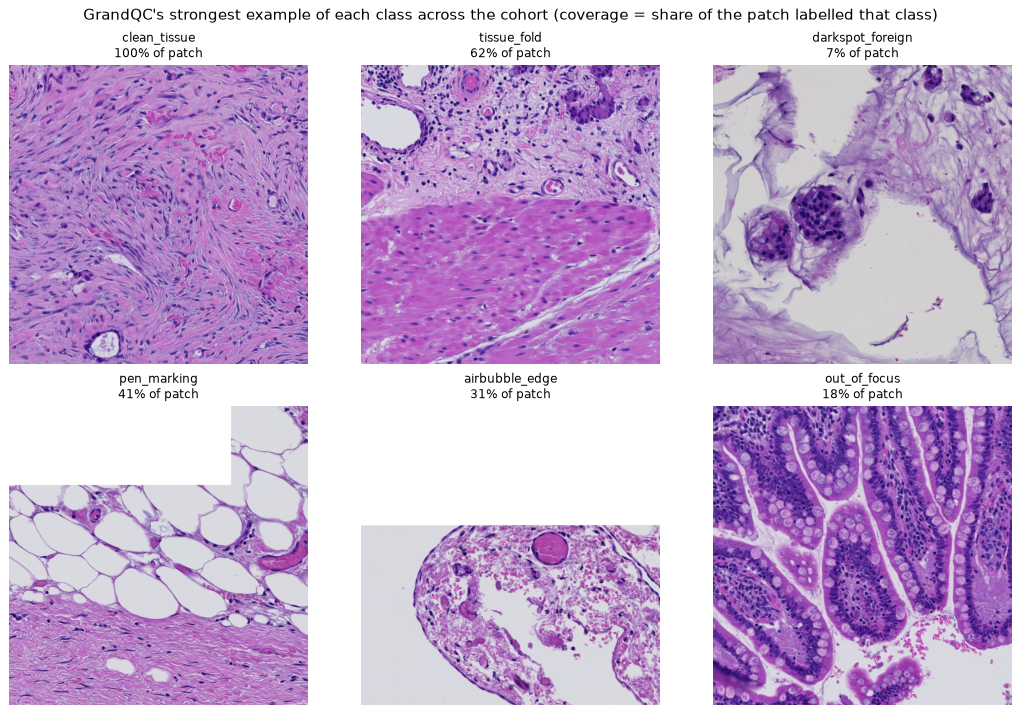

In [7]:
# One representative patch per class: across the cohort, the patch with the highest
# coverage of that class. Shows what GrandQC actually flags as each artifact type.
CLASSES_SHOWN = ["clean_tissue"] + ARTIFACTS

def best_patch(cls):
    """(slide, patch_index, coverage) for the cohort's highest-coverage patch of `cls`."""
    best = None
    for sl, rec in records.items():
        sc = rec["scores"][:, rec["classes"].index(cls)]
        i = int(np.argmax(sc))
        if best is None or sc[i] > best[2]:
            best = (sl, i, float(sc[i]))
    return best

picks = {cls: best_patch(cls) for cls in CLASSES_SHOWN}
by_slide = {}
for cls, (sl, i, cov) in picks.items():
    by_slide.setdefault(sl, []).append((cls, i, cov))

tiles = {}                                    # read each source slide once
for sl, items in by_slide.items():
    rec = records[sl]; p = rec["level0_patch"]
    with OmeZarrReader(sl) as r:
        for cls, i, cov in items:
            x, y = (int(v) for v in rec["coords"][i])
            tiles[cls] = (r.read_region(Region(level=0, location=Point(x, y), size=Size(p, p))), cov)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
for ax, cls in zip(axes.ravel(), CLASSES_SHOWN):
    tile, cov = tiles[cls]
    ax.imshow(tile); ax.set_title(f"{cls}\n{cov:.0%} of patch", fontsize=10); ax.axis("off")
fig.suptitle("GrandQC's strongest example of each class across the cohort "
             "(coverage = share of the patch labelled that class)")

## 6. Filter features by QC

Keep only patches that are mostly clean tissue, then index the feature matrix with that
mask. Same idea works for any threshold on any class (drop `out_of_focus > 0.5`, etc.).

In [8]:
root = open_root(store_for(slide))
g = root[GRIDS][qc["grid"]]
feats = np.asarray(g["features"]["resnet50"][:])
clean = qc["scores"][:, idx["clean_tissue"]] >= 0.8
print(f"{qc['grid']}: {feats.shape[0]} patches, {feats.shape[1]}-d features")
print(f"kept {clean.sum()} clean patches ({100*clean.mean():.0f}%), "
      f"dropped {int((~clean).sum())}")
clean_feats = feats[clean]
print("clean feature matrix:", clean_feats.shape)

mpp2_px224: 65 patches, 2048-d features
kept 26 clean patches (40%), dropped 39
clean feature matrix: (26, 2048)


---
**Notes.** GrandQC weights are CC-BY-NC-SA (non-commercial). We store the per-patch class
*fractions* (rich enough to threshold any artifact), not the full per-pixel raster. The
artifact checkpoints need a one-time conversion to a state_dict - see `docs/SEGMENTATION.md`.

---
**[raw2features](https://github.com/CraigMyles/raw2features)** · OME-Zarr WSIs → foundation-model embeddings · author **Craig Myles** · licence **MIT**

If you use raw2features, please cite it ([`CITATION.cff`](https://github.com/CraigMyles/raw2features/blob/main/CITATION.cff)). Pretrained encoders carry their own licences ([`MODEL_LICENSES.md`](https://github.com/CraigMyles/raw2features/blob/main/docs/MODEL_LICENSES.md)).